# DoubleML Tutorial 17: Common Pitfalls, Diagnostics, And Reporting

DoubleML is powerful because it separates a causal target from nuisance prediction. That separation is also where many applied analyses go wrong. A DoubleML estimate is not automatically credible just because the code runs, the learners are flexible, or the standard error is small. The estimate is credible only when the identification story, score construction, sample splitting, nuisance quality, and reporting all agree with each other.

The core partially linear regression design used throughout this notebook is:

$$
Y_i = \theta_0 D_i + g_0(X_i) + \varepsilon_i,
$$

$$
D_i = m_0(X_i) + V_i,
$$

with the causal target $\theta_0$. DoubleML estimates $g_0$ and $m_0$ with machine learning, residualizes both outcome and treatment, and solves an orthogonal score. For the partialling-out score, define:

$$
\hat{u}_i = Y_i - \hat{\ell}(X_i),
\qquad
\hat{v}_i = D_i - \hat{m}(X_i),
$$

where $\hat{\ell}(X_i)$ predicts $Y_i$ and $\hat{m}(X_i)$ predicts $D_i$. The score is:

$$
\psi_i(\theta) = \hat{v}_i\left(\hat{u}_i - \theta \hat{v}_i\right),
$$

and the fitted coefficient solves:

$$
\frac{1}{n}\sum_{i=1}^{n}\psi_i(\hat{\theta}) = 0.
$$

The important practical lesson is that orthogonality protects the final estimate from small nuisance errors, not from a broken design. If a confounder is missing, if a post-treatment variable is included as a control, if treatment has almost no residual variation, or if sample splitting is unstable, DoubleML will still produce a number. This notebook teaches how to detect and report those risks.

The notebook covers six applied failure modes:

- Omitted confounding that cannot be fixed by flexible learners.
- Bad controls and leakage, especially post-treatment variables.
- Weak residual treatment variation, the continuous-treatment version of poor overlap.
- Nuisance-model diagnostics that should be read as numerical checks, not causal proof.
- Sample-split sensitivity and repeated fitting.
- Reporting standards that make a DoubleML analysis auditable.

## Setup

This setup cell imports the libraries, creates tutorial output folders, and sets a writable Matplotlib cache directory before importing plotting libraries. That small environment step keeps notebook execution clean on machines where the default Matplotlib config directory is not writable.

In [1]:
from pathlib import Path
import os
import warnings

# Locate the repository root even when nbconvert executes from this notebook's directory.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate pyproject.toml; run this notebook from inside the repository.")

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MPLCONFIG_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MPLCONFIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ["MPLCONFIGDIR"] = str(MPLCONFIG_DIR)

# These filters are set before importing DoubleML because some optional notebook-widget
# warnings can be emitted during import in lightweight local environments.
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import doubleml as dml

from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

sns.set_theme(style="whitegrid", context="talk")

RANDOM_SEED = 1717
NOTEBOOK_PREFIX = "17"
TRUE_THETA = 1.0

print(f"DoubleML version: {dml.__version__}")
print(f"Writing artifacts under: {OUTPUT_DIR}")

DoubleML version: 0.11.2
Writing artifacts under: /home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs


The setup confirms that the notebook can import DoubleML and write artifacts into the tutorial output folders. All files created here use prefix `17` so they are easy to connect back to this notebook.

## Helper Functions

The helper functions keep the rest of the notebook readable. The most important helper is `fit_plr()`, which fits a `DoubleMLPLR` model and returns both the fitted object and a compact diagnostic row. The diagnostics intentionally combine causal and numerical information: coefficient error, confidence interval, nuisance RMSE, residual treatment variation, and the average score denominator.

In [2]:
def save_table(df, filename):
    """Save a table into the DoubleML tutorial table folder."""
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path


def save_dataset(df, filename):
    """Save a dataset into the DoubleML tutorial dataset folder."""
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return path


def rmse(y_true, y_pred):
    """Compute root mean squared error with explicit float output."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def extract_prediction(model, learner_name):
    """DoubleML stores predictions as n_obs x n_rep x n_treat arrays for this PLR setup."""
    return model.predictions[learner_name][:, 0, 0]


def fit_plr(df, x_cols, learner_l, learner_m, label, true_theta=TRUE_THETA, sample_splits=None):
    """Fit a PLR model and return the fitted model plus a one-row diagnostic dictionary."""
    data = dml.DoubleMLData(df, y_col="outcome", d_cols="treatment", x_cols=x_cols)
    model = dml.DoubleMLPLR(
        data,
        ml_l=clone(learner_l),
        ml_m=clone(learner_m),
        n_folds=5,
        score="partialling out",
    )

    if sample_splits is not None:
        model.set_sample_splitting(sample_splits)

    model.fit(store_predictions=True)

    y_hat = extract_prediction(model, "ml_l")
    d_hat = extract_prediction(model, "ml_m")
    residualized_treatment = df["treatment"].to_numpy() - d_hat
    psi_a = model.psi_elements["psi_a"].reshape(-1)
    coef = float(model.coef[0])
    se = float(model.se[0])

    row = {
        "model": label,
        "n_controls": len(x_cols),
        "estimate": coef,
        "std_error": se,
        "ci_95_lower": coef - 1.96 * se,
        "ci_95_upper": coef + 1.96 * se,
        "true_theta": true_theta,
        "absolute_error": abs(coef - true_theta),
        "outcome_rmse": rmse(df["outcome"], y_hat),
        "treatment_rmse": rmse(df["treatment"], d_hat),
        "resid_treatment_sd": float(np.std(residualized_treatment)),
        "mean_resid_treatment_sq": float(np.mean(residualized_treatment**2)),
        "score_denominator": float(-np.mean(psi_a)),
    }
    return model, row


def make_kfold_splits(n_obs, seed, n_splits=5):
    """Create a DoubleML-compatible one-repetition list of train/test folds."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return [(train_idx, test_idx) for train_idx, test_idx in kfold.split(np.arange(n_obs))]

The helper output will let us compare scenarios without hiding the mechanics. When a later table shows a bad estimate, the same row also shows whether nuisance prediction, residual treatment variation, or the control set changed.

## Pitfall Map

Before running code, it helps to name the failure modes. DoubleML is an estimator, not an identification oracle. The table below separates problems that come from the causal design from problems that come from implementation or reporting.

In [3]:
pitfall_map = pd.DataFrame(
    [
        {
            "pitfall": "Omitted confounding",
            "where_it_enters": "Identification",
            "symptom": "Estimate changes sharply when an important pre-treatment confounder is added or removed.",
            "recommended_check": "State the adjustment set and run negative-control or sensitivity checks when possible.",
        },
        {
            "pitfall": "Bad controls or leakage",
            "where_it_enters": "Feature design",
            "symptom": "Including post-treatment variables can shrink, reverse, or otherwise distort the causal estimate.",
            "recommended_check": "Classify every feature by time: pre-treatment, treatment, mediator, outcome, or future signal.",
        },
        {
            "pitfall": "Weak residual treatment variation",
            "where_it_enters": "Overlap or positivity",
            "symptom": "The residualized treatment has very small variance and standard errors inflate.",
            "recommended_check": "Inspect residualized-treatment distributions and the score denominator.",
        },
        {
            "pitfall": "Poor nuisance models",
            "where_it_enters": "Estimation",
            "symptom": "Nuisance RMSE is high or unstable across learners and folds.",
            "recommended_check": "Compare learners, tune deliberately, and report nuisance diagnostics.",
        },
        {
            "pitfall": "Sample-split luck",
            "where_it_enters": "Cross-fitting",
            "symptom": "Estimates move materially across random fold assignments.",
            "recommended_check": "Use repeated cross-fitting or rerun over several deterministic seeds.",
        },
        {
            "pitfall": "Under-reporting",
            "where_it_enters": "Communication",
            "symptom": "Readers cannot tell what data, learners, score, folds, or assumptions produced the estimate.",
            "recommended_check": "Publish a compact design table, diagnostics table, and limitation statement.",
        },
    ]
)

save_table(pitfall_map, f"{NOTEBOOK_PREFIX}_pitfall_map.csv")
display(pitfall_map)

,pitfall,where_it_enters,symptom,recommended_check
0,Omitted confounding,Identification,Estimate changes sharply when an important pre...,State the adjustment set and run negative-cont...
1,Bad controls or leakage,Feature design,"Including post-treatment variables can shrink,...","Classify every feature by time: pre-treatment,..."
2,Weak residual treatment variation,Overlap or positivity,The residualized treatment has very small vari...,Inspect residualized-treatment distributions a...
3,Poor nuisance models,Estimation,Nuisance RMSE is high or unstable across learn...,"Compare learners, tune deliberately, and repor..."
4,Sample-split luck,Cross-fitting,Estimates move materially across random fold a...,Use repeated cross-fitting or rerun over sever...
5,Under-reporting,Communication,"Readers cannot tell what data, learners, score...","Publish a compact design table, diagnostics ta..."


The map is the checklist for the rest of the notebook. The examples below do not try to exhaust every possible failure. They show the kinds of evidence a careful analyst should collect before trusting a DoubleML result.

## Simulate A Known-Truth Confounding Design

The first simulation makes confounding visible. The column `latent_need` acts like a strong pre-treatment confounder. We include it in the dataset so we can demonstrate what happens when it is included, omitted, or replaced with a bad post-treatment feature. In a real observational dataset, the dangerous version is worse: the confounder may be absent entirely.

The data-generating process is linear so that a well-specified baseline has a fair chance to recover the true value:

$$
D_i = h_D(X_i, U_i) + V_i,
$$

$$
Y_i = \theta_0 D_i + h_Y(X_i, U_i) + \varepsilon_i,
$$

where $U_i$ is represented by `latent_need` for teaching purposes. The true effect is $\theta_0 = 1.0$.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 1_800
n_features = 8
feature_cols = [f"x{j:02d}" for j in range(n_features)]

X = rng.normal(size=(n_obs, n_features))
latent_need = 0.8 * X[:, 0] - 0.5 * X[:, 2] + rng.normal(size=n_obs)

treatment_signal = 0.8 * X[:, 0] - 0.6 * X[:, 1] + 0.7 * X[:, 3] + 0.9 * latent_need
treatment = treatment_signal + rng.normal(scale=1.0, size=n_obs)

outcome_signal = 0.7 * X[:, 0] + 0.5 * X[:, 2] - 0.4 * X[:, 4] + 1.3 * latent_need
outcome = TRUE_THETA * treatment + outcome_signal + rng.normal(scale=1.0, size=n_obs)

# This is intentionally bad: it is built from the realized outcome and treatment.
post_outcome_proxy = 0.65 * outcome + 0.25 * treatment + rng.normal(scale=0.6, size=n_obs)

confounding_df = pd.DataFrame(X, columns=feature_cols)
confounding_df["latent_need"] = latent_need
confounding_df["post_outcome_proxy"] = post_outcome_proxy
confounding_df["treatment"] = treatment
confounding_df["outcome"] = outcome

save_dataset(confounding_df, f"{NOTEBOOK_PREFIX}_confounding_pitfall_data.csv")
confounding_df.head()

,x00,x01,x02,x03,x04,x05,x06,x07,latent_need,post_outcome_proxy,treatment,outcome
0,-0.442486,-1.011796,1.201736,2.003726,-1.765337,0.989969,-0.073723,0.550082,-1.794301,-0.766049,0.959050,-0.799115
1,0.554699,1.422543,2.628656,0.815418,-0.014838,-1.169905,-0.249729,0.077894,-0.993645,-2.153806,-1.056584,-1.598617
2,-0.366996,-0.303584,-0.234200,0.274319,0.254770,0.347296,-0.393850,0.151550,0.585688,1.512251,0.909832,2.748031
3,0.286510,-0.129636,-0.545928,1.210361,1.064770,-1.940194,0.587672,-1.605602,1.530225,5.508370,4.771020,6.434808
4,-0.104771,-0.211868,0.117987,-0.021909,0.121693,-1.511996,-1.307896,0.595820,-0.064173,-0.275525,0.830392,-0.186563


The first rows show ordinary pre-treatment controls, the teaching confounder `latent_need`, the intentionally invalid `post_outcome_proxy`, the treatment, and the outcome. The next step is to document these fields so the control-set choices are explicit instead of hidden inside model code.

## Field Dictionary

Feature timing is one of the most important reporting details in causal work. A variable can be predictive and still be invalid as a control. The table below classifies each group of columns by causal role.

In [5]:
field_dictionary = pd.DataFrame(
    [
        {
            "field_group": "x00 to x07",
            "role": "Observed pre-treatment controls",
            "safe_for_adjustment": "Yes",
            "notes": "Baseline covariates measured before treatment assignment.",
        },
        {
            "field_group": "latent_need",
            "role": "Strong pre-treatment confounder used for teaching",
            "safe_for_adjustment": "Yes, if it is genuinely observed before treatment",
            "notes": "Omitting it creates a controlled demonstration of unmeasured-confounding bias.",
        },
        {
            "field_group": "post_outcome_proxy",
            "role": "Post-treatment leakage variable",
            "safe_for_adjustment": "No",
            "notes": "It is partly constructed from outcome and treatment, so adjusting for it changes the causal question.",
        },
        {
            "field_group": "treatment",
            "role": "Continuous treatment D",
            "safe_for_adjustment": "Target treatment, not a control",
            "notes": "The effect of this variable on outcome is the target of estimation.",
        },
        {
            "field_group": "outcome",
            "role": "Outcome Y",
            "safe_for_adjustment": "No",
            "notes": "This is the response variable, not a feature for the nuisance models.",
        },
    ]
)

save_table(field_dictionary, f"{NOTEBOOK_PREFIX}_field_dictionary.csv")
display(field_dictionary)

,field_group,role,safe_for_adjustment,notes
0,x00 to x07,Observed pre-treatment controls,Yes,Baseline covariates measured before treatment ...
1,latent_need,Strong pre-treatment confounder used for teaching,"Yes, if it is genuinely observed before treatment",Omitting it creates a controlled demonstration...
2,post_outcome_proxy,Post-treatment leakage variable,No,It is partly constructed from outcome and trea...
3,treatment,Continuous treatment D,"Target treatment, not a control",The effect of this variable on outcome is the ...
4,outcome,Outcome Y,No,"This is the response variable, not a feature f..."


The dictionary makes the coming scenarios easier to judge. Including `latent_need` is valid in this teaching dataset because it is pre-treatment. Including `post_outcome_proxy` is not valid even though it will be highly predictive.

## Design Diagram

The diagram summarizes the first simulation. Solid arrows show the intended causal and confounding structure. The dashed arrow marks the bad-control path created when a post-treatment proxy is included as if it were a baseline covariate.

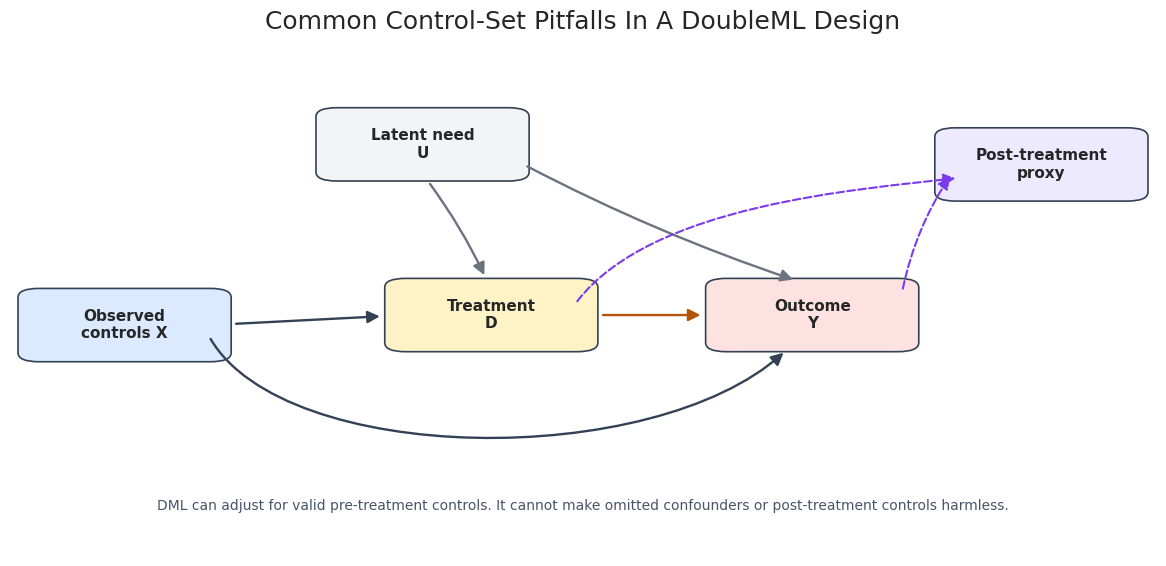

In [6]:
from matplotlib.path import Path as MplPath

nodes = {
    "X": {"xy": (0.10, 0.46), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "U": {"xy": (0.36, 0.82), "label": "Latent need\nU", "color": "#f3f4f6"},
    "D": {"xy": (0.42, 0.48), "label": "Treatment\nD", "color": "#fef3c7"},
    "Y": {"xy": (0.70, 0.48), "label": "Outcome\nY", "color": "#fee2e2"},
    "P": {"xy": (0.90, 0.78), "label": "Post-treatment\nproxy", "color": "#ede9fe"},
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()
box_w, box_h = 0.15, 0.11


def anchor(node, side):
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return np.array([x + dx, y + dy], dtype=float)


def shorten(start, end, gap=0.020):
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)


def draw_arrow(start, end, color="#334155", style="solid", rad=0.0, linewidth=1.7):
    start, end = shorten(start, end)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=5,
        clip_on=False,
    )
    ax.add_patch(arrow)


def draw_bezier_arrow(start, control_1, control_2, end, color="#334155", style="solid", linewidth=1.7):
    # Use one continuous cubic Bezier path so routed arrows never appear broken.
    vertices = [tuple(start), tuple(control_1), tuple(control_2), tuple(end)]
    codes = [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4]
    path = MplPath(vertices, codes)
    arrow = FancyArrowPatch(
        path=path,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        zorder=5,
        clip_on=False,
    )
    ax.add_patch(arrow)

# Draw arrows before boxes so node labels stay readable, but keep every arrow as one continuous patch.
draw_arrow(anchor("X", "right"), anchor("D", "left"), color="#334155")
draw_bezier_arrow(
    anchor("X", "lower_right"),
    np.array([0.24, 0.18]),
    np.array([0.56, 0.17]),
    anchor("Y", "bottom") + np.array([-0.025, -0.020]),
    color="#334155",
)
draw_arrow(anchor("U", "bottom"), anchor("D", "top"), color="#6b7280", rad=-0.05)
draw_arrow(anchor("U", "lower_right"), anchor("Y", "top"), color="#6b7280", rad=0.04)
draw_arrow(anchor("D", "right"), anchor("Y", "left"), color="#b45309")
draw_arrow(anchor("Y", "upper_right"), anchor("P", "left"), color="#7c3aed", style="dashed", rad=-0.10, linewidth=1.5)
draw_bezier_arrow(
    anchor("D", "upper_right"),
    np.array([0.56, 0.70]),
    np.array([0.74, 0.73]),
    anchor("P", "lower_left"),
    color="#7c3aed",
    style="dashed",
    linewidth=1.5,
)

for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

ax.text(
    0.50,
    0.10,
    "DML can adjust for valid pre-treatment controls. It cannot make omitted confounders or post-treatment controls harmless.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Common Control-Set Pitfalls In A DoubleML Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_control_set_pitfall_dag.png", dpi=160, bbox_inches="tight")
plt.show()

The diagram is a compact reminder of the control-set rule. Valid controls are measured before treatment and help block backdoor paths. A post-treatment proxy is not made valid by being predictive.

## Fit Control-Set Scenarios

Now we fit four versions of the same PLR analysis. The only thing that changes is the feature set. This isolates a central lesson: DoubleML can only adjust for the variables we give it, and giving it the wrong variables can be worse than giving it too few.

In [7]:
linear_learner = LassoCV(cv=5, random_state=RANDOM_SEED, max_iter=10_000)

control_sets = {
    "Valid controls including latent_need": feature_cols + ["latent_need"],
    "Omitted latent_need": feature_cols,
    "Too few controls": ["x00", "x01"],
    "Bad post-treatment control": feature_cols + ["latent_need", "post_outcome_proxy"],
}

control_models = {}
control_rows = []
for label, x_cols in control_sets.items():
    model, row = fit_plr(
        confounding_df,
        x_cols=x_cols,
        learner_l=linear_learner,
        learner_m=linear_learner,
        label=label,
    )
    control_models[label] = model
    control_rows.append(row)

control_results = pd.DataFrame(control_rows).sort_values("absolute_error")
save_table(control_results, f"{NOTEBOOK_PREFIX}_control_set_scenarios.csv")
display(control_results)

,model,n_controls,estimate,std_error,ci_95_lower,ci_95_upper,true_theta,absolute_error,outcome_rmse,treatment_rmse,resid_treatment_sd,mean_resid_treatment_sq,score_denominator
0,Valid controls including latent_need,9,1.014635,0.023971,0.967653,1.061617,1.0,0.014635,1.455148,1.013755,1.013753,1.027699,1.027699
2,Too few controls,2,1.516020,0.021867,1.473160,1.558879,1.0,0.516020,2.872831,1.598900,1.598900,2.556481,2.556481
1,Omitted latent_need,8,1.666425,0.024446,1.618512,1.714338,1.0,0.666425,2.680577,1.361909,1.361909,1.854797,1.854797
3,Bad post-treatment control,10,0.254628,0.022369,0.210784,0.298471,1.0,0.745372,0.715605,0.711764,0.711763,0.506608,0.506608


The valid-control model is closest to the known truth. Omitting the strong confounder pushes the estimate upward, while adding a post-treatment proxy severely distorts the answer. The table is deliberately blunt: accurate prediction and valid adjustment are different goals.

## Plot Control-Set Estimates

A plot makes the control-set risk easier to scan. The vertical line marks the true effect used by the simulator, and each interval is a normal 95% confidence interval from the fitted DoubleML model.

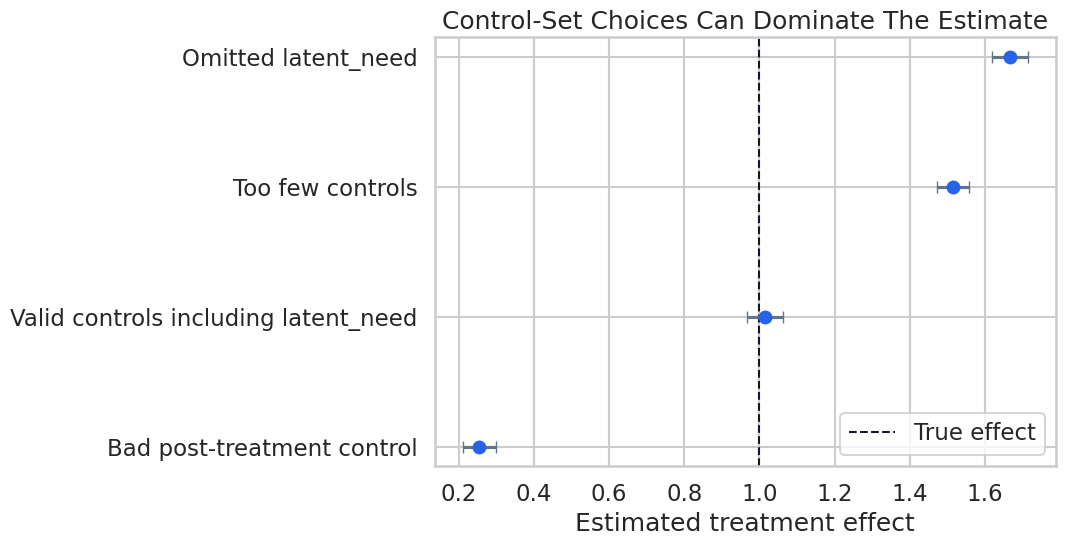

In [8]:
plot_df = control_results.sort_values("estimate").copy()
plot_df["lower_error"] = plot_df["estimate"] - plot_df["ci_95_lower"]
plot_df["upper_error"] = plot_df["ci_95_upper"] - plot_df["estimate"]

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.axvline(TRUE_THETA, color="#111827", linestyle="--", linewidth=1.5, label="True effect")
ax.errorbar(
    x=plot_df["estimate"],
    y=np.arange(len(plot_df)),
    xerr=[plot_df["lower_error"], plot_df["upper_error"]],
    fmt="o",
    color="#2563eb",
    ecolor="#64748b",
    capsize=4,
)
ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(plot_df["model"])
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.set_title("Control-Set Choices Can Dominate The Estimate")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_control_set_estimates.png", dpi=160, bbox_inches="tight")
plt.show()

The visual gap between scenarios is the main lesson. A narrow interval around a biased estimate is still a bad causal result. Reporting only one preferred specification would hide the fragility created by the control set.

## Residual And Nuisance Diagnostics

DoubleML estimates rely on nuisance models, but nuisance diagnostics should be read carefully. Low RMSE is useful; it is not proof that the adjustment set is valid. This cell compares nuisance prediction quality and residualized-treatment variation across the control-set scenarios.

In [9]:
diagnostic_cols = [
    "model",
    "outcome_rmse",
    "treatment_rmse",
    "resid_treatment_sd",
    "mean_resid_treatment_sq",
    "score_denominator",
    "absolute_error",
]

control_diagnostics = control_results[diagnostic_cols].sort_values("absolute_error")
save_table(control_diagnostics, f"{NOTEBOOK_PREFIX}_control_set_diagnostics.csv")
display(control_diagnostics)

,model,outcome_rmse,treatment_rmse,resid_treatment_sd,mean_resid_treatment_sq,score_denominator,absolute_error
0,Valid controls including latent_need,1.455148,1.013755,1.013753,1.027699,1.027699,0.014635
2,Too few controls,2.872831,1.598900,1.598900,2.556481,2.556481,0.516020
1,Omitted latent_need,2.680577,1.361909,1.361909,1.854797,1.854797,0.666425
3,Bad post-treatment control,0.715605,0.711764,0.711763,0.506608,0.506608,0.745372


The bad post-treatment control can look numerically attractive because it predicts outcome-related variation. That is exactly why timing metadata matters. A diagnostic can tell us how a learner behaved; it cannot decide whether a feature belongs in the causal design.

## Weak Residual Treatment Variation

For a continuous treatment, overlap shows up as residual treatment variation after adjusting for controls. If the treatment is almost deterministic given the controls, then $\hat{v}_i = D_i - \hat{m}(X_i)$ is tiny. The score denominator becomes small, and the estimate can become noisy.

This simulation changes only the treatment-noise scale. Smaller treatment noise means weaker residual variation.

In [10]:
def make_overlap_data(treatment_noise_sd, seed):
    rng = np.random.default_rng(seed)
    n_obs = 1_600
    n_features = 8
    X = rng.normal(size=(n_obs, n_features))
    latent_need = 0.8 * X[:, 0] - 0.5 * X[:, 2] + rng.normal(size=n_obs)

    treatment_signal = 0.8 * X[:, 0] - 0.6 * X[:, 1] + 0.7 * X[:, 3] + 0.9 * latent_need
    treatment = treatment_signal + rng.normal(scale=treatment_noise_sd, size=n_obs)
    outcome_signal = 0.7 * X[:, 0] + 0.5 * X[:, 2] - 0.4 * X[:, 4] + 1.3 * latent_need
    outcome = TRUE_THETA * treatment + outcome_signal + rng.normal(scale=1.0, size=n_obs)

    df = pd.DataFrame(X, columns=feature_cols)
    df["latent_need"] = latent_need
    df["treatment"] = treatment
    df["outcome"] = outcome
    return df

noise_levels = [1.00, 0.35, 0.15]
overlap_rows = []
overlap_models = {}

for noise_sd in noise_levels:
    overlap_df = make_overlap_data(treatment_noise_sd=noise_sd, seed=RANDOM_SEED + int(noise_sd * 1000))
    label = f"Treatment noise sd = {noise_sd:.2f}"
    model, row = fit_plr(
        overlap_df,
        x_cols=feature_cols + ["latent_need"],
        learner_l=linear_learner,
        learner_m=linear_learner,
        label=label,
    )
    row["treatment_noise_sd"] = noise_sd
    overlap_rows.append(row)
    overlap_models[label] = (model, overlap_df)

overlap_results = pd.DataFrame(overlap_rows).sort_values("treatment_noise_sd", ascending=False)
save_table(overlap_results, f"{NOTEBOOK_PREFIX}_residual_treatment_variation.csv")
display(overlap_results[["model", "estimate", "std_error", "resid_treatment_sd", "mean_resid_treatment_sq", "score_denominator", "absolute_error"]])

,model,estimate,std_error,resid_treatment_sd,mean_resid_treatment_sq,score_denominator,absolute_error
0,Treatment noise sd = 1.00,0.980651,0.027116,0.985201,0.970622,0.970622,0.019349
1,Treatment noise sd = 0.35,1.204531,0.069996,0.343812,0.118207,0.118207,0.204531
2,Treatment noise sd = 0.15,0.907768,0.146815,0.152821,0.023354,0.023354,0.092232


As residual treatment variation gets smaller, the standard error grows and the estimate becomes more fragile. This is not a learner failure; it is a design problem. There is not enough treatment movement left after adjustment to estimate the slope precisely.

## Plot Residual Treatment Variation

The next plot shows the distribution of residualized treatment for each noise level. This is the continuous-treatment diagnostic behind the previous table.

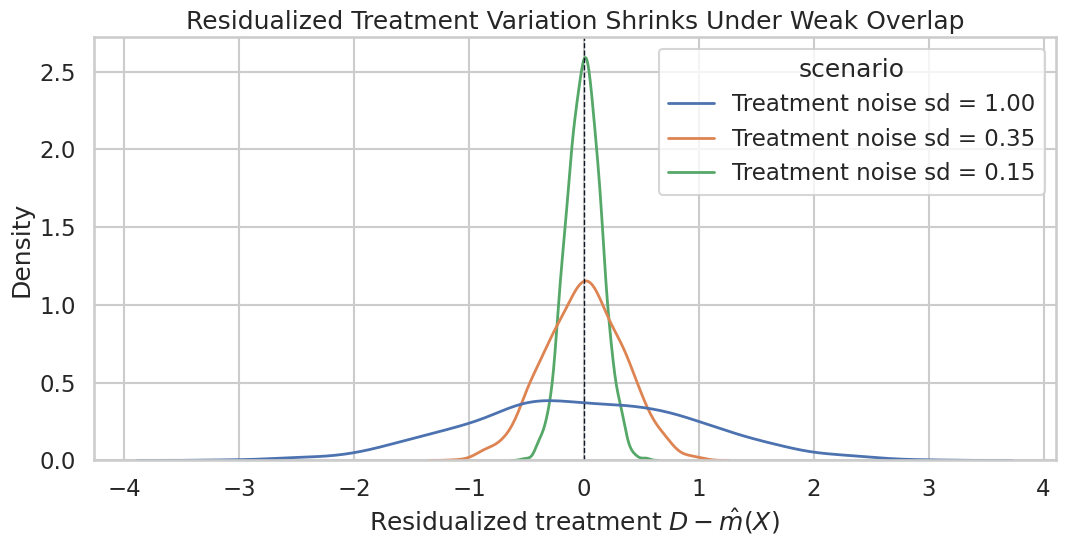

In [11]:
residual_plot_frames = []
for label, (model, df) in overlap_models.items():
    d_hat = extract_prediction(model, "ml_m")
    residual_plot_frames.append(
        pd.DataFrame(
            {
                "scenario": label,
                "residualized_treatment": df["treatment"].to_numpy() - d_hat,
            }
        )
    )

residual_plot_df = pd.concat(residual_plot_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 5.8))
sns.kdeplot(
    data=residual_plot_df,
    x="residualized_treatment",
    hue="scenario",
    common_norm=False,
    linewidth=2,
    ax=ax,
)
ax.axvline(0, color="#111827", linestyle="--", linewidth=1)
ax.set_title("Residualized Treatment Variation Shrinks Under Weak Overlap")
ax.set_xlabel(r"Residualized treatment $D - \hat{m}(X)$")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_residualized_treatment_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

The narrowest curve corresponds to the weakest residual variation. A DoubleML report should include this kind of diagnostic when the treatment is continuous or when treatment assignment is highly predictable from controls.

## Nuisance Learner Comparison

The next simulation is nonlinear. The goal is not to prove that one learner is always best. The goal is to show how to compare nuisance learners without mistaking predictive performance for identification. We compare a simple linear learner with a random forest on the same known-truth design.

In [12]:
def make_nonlinear_data(seed):
    rng = np.random.default_rng(seed)
    n_obs = 1_600
    X = rng.normal(size=(n_obs, len(feature_cols)))

    m0 = 1.1 * np.sin(X[:, 0]) + 0.7 * X[:, 1] * X[:, 2] - 0.6 * (X[:, 3] > 0) + 0.3 * X[:, 4] ** 2
    treatment = m0 + rng.normal(scale=1.0, size=n_obs)
    g0 = 0.9 * np.cos(X[:, 0]) + 0.8 * X[:, 2] ** 2 - 0.4 * X[:, 5] * X[:, 6]
    outcome = TRUE_THETA * treatment + g0 + rng.normal(scale=1.0, size=n_obs)

    df = pd.DataFrame(X, columns=feature_cols)
    df["treatment"] = treatment
    df["outcome"] = outcome
    return df

nonlinear_df = make_nonlinear_data(RANDOM_SEED + 404)
save_dataset(nonlinear_df, f"{NOTEBOOK_PREFIX}_nonlinear_nuisance_data.csv")

learner_specs = {
    "Linear regression": LinearRegression(),
    "Random forest": RandomForestRegressor(
        n_estimators=220,
        min_samples_leaf=8,
        max_features="sqrt",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

learner_rows = []
learner_models = {}
for label, learner in learner_specs.items():
    model, row = fit_plr(
        nonlinear_df,
        x_cols=feature_cols,
        learner_l=learner,
        learner_m=learner,
        label=label,
    )
    learner_rows.append(row)
    learner_models[label] = model

learner_results = pd.DataFrame(learner_rows).sort_values("outcome_rmse")
save_table(learner_results, f"{NOTEBOOK_PREFIX}_nuisance_learner_comparison.csv")
display(learner_results[["model", "estimate", "std_error", "absolute_error", "outcome_rmse", "treatment_rmse", "resid_treatment_sd"]])

,model,estimate,std_error,absolute_error,outcome_rmse,treatment_rmse,resid_treatment_sd
1,Random forest,0.957288,0.027294,0.042712,1.651002,1.195607,1.195581
0,Linear regression,0.934986,0.034595,0.065014,1.939093,1.284264,1.284263


The random forest improves nuisance prediction in this nonlinear design. The causal estimate is still judged against the known truth, not against RMSE alone. In real data, we do not know the true effect, so this table becomes evidence about numerical plausibility rather than final validation.

## Plot Learner Diagnostics

This plot puts the nuisance-model comparison into one view: treatment-effect error on one axis and nuisance RMSE on the other. It is a compact way to discuss whether better nuisance prediction also produced a more stable target estimate.

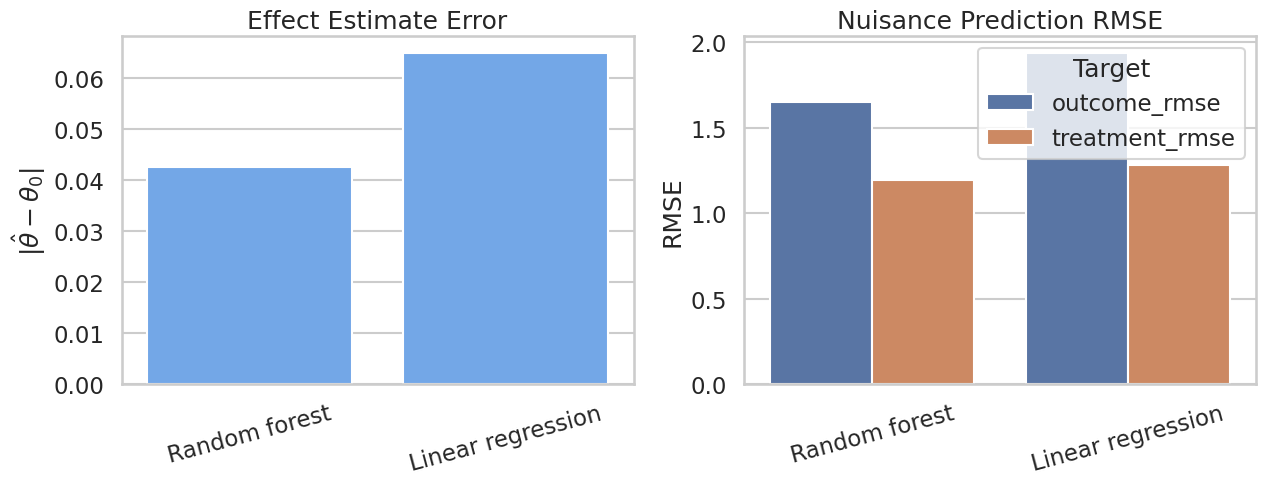

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.barplot(
    data=learner_results,
    x="model",
    y="absolute_error",
    color="#60a5fa",
    ax=axes[0],
)
axes[0].set_title("Effect Estimate Error")
axes[0].set_xlabel("")
axes[0].set_ylabel(r"$|\hat{\theta} - \theta_0|$")
axes[0].tick_params(axis="x", rotation=15)

nuisance_long = learner_results.melt(
    id_vars="model",
    value_vars=["outcome_rmse", "treatment_rmse"],
    var_name="nuisance_target",
    value_name="rmse",
)
sns.barplot(
    data=nuisance_long,
    x="model",
    y="rmse",
    hue="nuisance_target",
    ax=axes[1],
)
axes[1].set_title("Nuisance Prediction RMSE")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Target", loc="upper right")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nuisance_learner_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

The two panels should be read together. Strong nuisance models are helpful, but the report should not claim that a lower prediction error proves the causal estimate. Prediction diagnostics support the estimation story; they do not replace the assumptions.

## Sample-Split Sensitivity

Cross-fitting uses fold assignments. A single random split is usually not the whole story. This cell refits the same valid-control design over multiple fixed fold seeds and records how much the estimate moves.

In [14]:
split_rows = []
split_seeds = list(range(RANDOM_SEED, RANDOM_SEED + 14))
valid_x_cols = feature_cols + ["latent_need"]

for seed in split_seeds:
    sample_splits = make_kfold_splits(len(confounding_df), seed=seed, n_splits=5)
    model, row = fit_plr(
        confounding_df,
        x_cols=valid_x_cols,
        learner_l=linear_learner,
        learner_m=linear_learner,
        label=f"split_seed_{seed}",
        sample_splits=sample_splits,
    )
    row["split_seed"] = seed
    split_rows.append(row)

split_results = pd.DataFrame(split_rows)
split_summary = pd.DataFrame(
    [
        {
            "n_repetitions": len(split_results),
            "mean_estimate": split_results["estimate"].mean(),
            "sd_estimate": split_results["estimate"].std(ddof=1),
            "min_estimate": split_results["estimate"].min(),
            "max_estimate": split_results["estimate"].max(),
            "mean_std_error": split_results["std_error"].mean(),
            "true_theta": TRUE_THETA,
        }
    ]
)

save_table(split_results, f"{NOTEBOOK_PREFIX}_sample_split_repetitions.csv")
save_table(split_summary, f"{NOTEBOOK_PREFIX}_sample_split_summary.csv")
display(split_summary)

,n_repetitions,mean_estimate,sd_estimate,min_estimate,max_estimate,mean_std_error,true_theta
0,14,1.013214,0.001735,1.009349,1.016719,0.023996,1.0


The split summary tells us whether one fold assignment was unusually lucky or unlucky. In this clean simulation, the repeated estimates should be fairly stable. In noisier real applications, this can be one of the most useful robustness checks.

## Plot Sample-Split Stability

The next plot shows each repeated estimate and the known true effect. This is a simple visual habit that makes cross-fitting randomness visible.

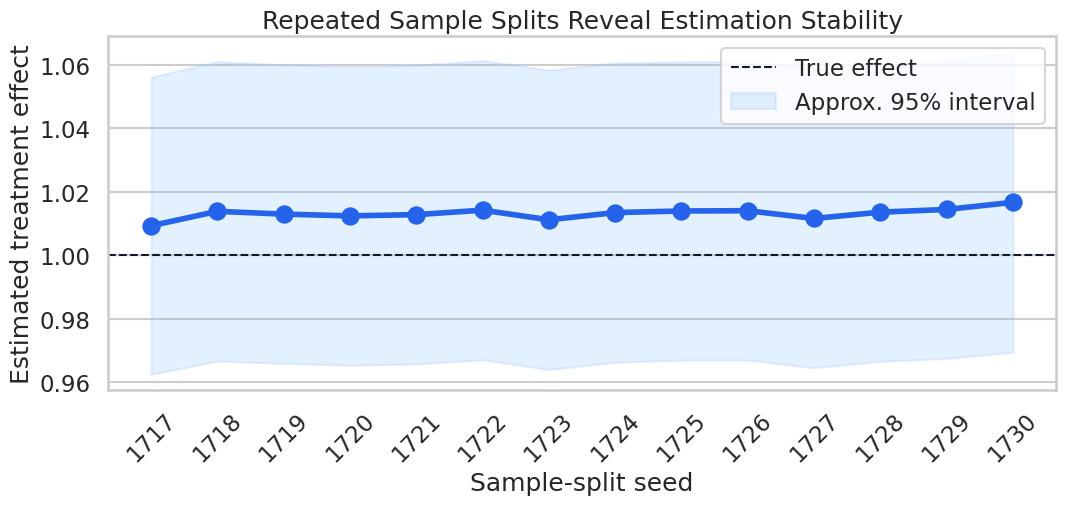

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.4))
ax.axhline(TRUE_THETA, color="#111827", linestyle="--", linewidth=1.5, label="True effect")
sns.pointplot(
    data=split_results,
    x="split_seed",
    y="estimate",
    color="#2563eb",
    errorbar=None,
    ax=ax,
)
ax.fill_between(
    np.arange(len(split_results)),
    split_results.sort_values("split_seed")["estimate"] - 1.96 * split_results.sort_values("split_seed")["std_error"],
    split_results.sort_values("split_seed")["estimate"] + 1.96 * split_results.sort_values("split_seed")["std_error"],
    color="#93c5fd",
    alpha=0.25,
    label="Approx. 95% interval",
)
ax.set_title("Repeated Sample Splits Reveal Estimation Stability")
ax.set_xlabel("Sample-split seed")
ax.set_ylabel("Estimated treatment effect")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_split_stability.png", dpi=160, bbox_inches="tight")
plt.show()

The estimates cluster tightly in this example. If the dots jumped across substantively different values, the report should say so and either use repeated cross-fitting or explain why the design is unstable.

## Diagnostic Scorecard

A good DoubleML report should not bury diagnostics in scattered notebook cells. This scorecard converts the previous examples into a compact review table. The goal is to make it easy to see which risks were checked, what evidence was produced, and what remains unresolved.

In [16]:
valid_row = control_results.loc[control_results["model"].eq("Valid controls including latent_need")].iloc[0]
omitted_row = control_results.loc[control_results["model"].eq("Omitted latent_need")].iloc[0]
bad_control_row = control_results.loc[control_results["model"].eq("Bad post-treatment control")].iloc[0]
weak_overlap_row = overlap_results.loc[overlap_results["treatment_noise_sd"].eq(0.15)].iloc[0]

scorecard = pd.DataFrame(
    [
        {
            "risk_area": "Confounding",
            "evidence_from_notebook": f"Omitting latent_need changed estimate from {valid_row['estimate']:.3f} to {omitted_row['estimate']:.3f}.",
            "status": "Requires design justification",
            "reporting_action": "State adjustment set and discuss unavailable confounders.",
        },
        {
            "risk_area": "Bad controls",
            "evidence_from_notebook": f"Adding post_outcome_proxy moved estimate to {bad_control_row['estimate']:.3f}.",
            "status": "High risk if included",
            "reporting_action": "Classify variables by measurement time and exclude post-treatment controls.",
        },
        {
            "risk_area": "Residual treatment variation",
            "evidence_from_notebook": f"Weakest scenario residual SD is {weak_overlap_row['resid_treatment_sd']:.3f} with SE {weak_overlap_row['std_error']:.3f}.",
            "status": "Check required",
            "reporting_action": "Show residualized-treatment distribution or equivalent overlap diagnostic.",
        },
        {
            "risk_area": "Nuisance quality",
            "evidence_from_notebook": "Linear and forest learners were compared on a nonlinear design.",
            "status": "Model-dependent",
            "reporting_action": "Report learner settings, nuisance RMSE, and tuning choices.",
        },
        {
            "risk_area": "Sample splitting",
            "evidence_from_notebook": f"Repeated split SD is {split_summary.loc[0, 'sd_estimate']:.4f}.",
            "status": "Stable in this simulation",
            "reporting_action": "Report fold count, repetition count, and random seeds.",
        },
        {
            "risk_area": "Communication",
            "evidence_from_notebook": "Tables and figures are saved as reviewable artifacts.",
            "status": "Report explicitly",
            "reporting_action": "Include assumptions, diagnostics, limitations, and artifact paths.",
        },
    ]
)

save_table(scorecard, f"{NOTEBOOK_PREFIX}_diagnostic_scorecard.csv")
display(scorecard)

,risk_area,evidence_from_notebook,status,reporting_action
0,Confounding,Omitting latent_need changed estimate from 1.0...,Requires design justification,State adjustment set and discuss unavailable c...
1,Bad controls,Adding post_outcome_proxy moved estimate to 0....,High risk if included,Classify variables by measurement time and exc...
2,Residual treatment variation,Weakest scenario residual SD is 0.153 with SE ...,Check required,Show residualized-treatment distribution or eq...
3,Nuisance quality,Linear and forest learners were compared on a ...,Model-dependent,"Report learner settings, nuisance RMSE, and tu..."
4,Sample splitting,Repeated split SD is 0.0017.,Stable in this simulation,"Report fold count, repetition count, and rando..."
5,Communication,Tables and figures are saved as reviewable art...,Report explicitly,"Include assumptions, diagnostics, limitations,..."


The scorecard is intentionally plain. A reader should be able to understand the main risks without rerunning the entire notebook. The most important unresolved item in real data is usually confounding that was not measured.

## Plot Diagnostic Scorecard

A small heatmap-style display can help summarize which risks are resolved, checked, or still dependent on assumptions. This is not a statistical test. It is a communication device for review.

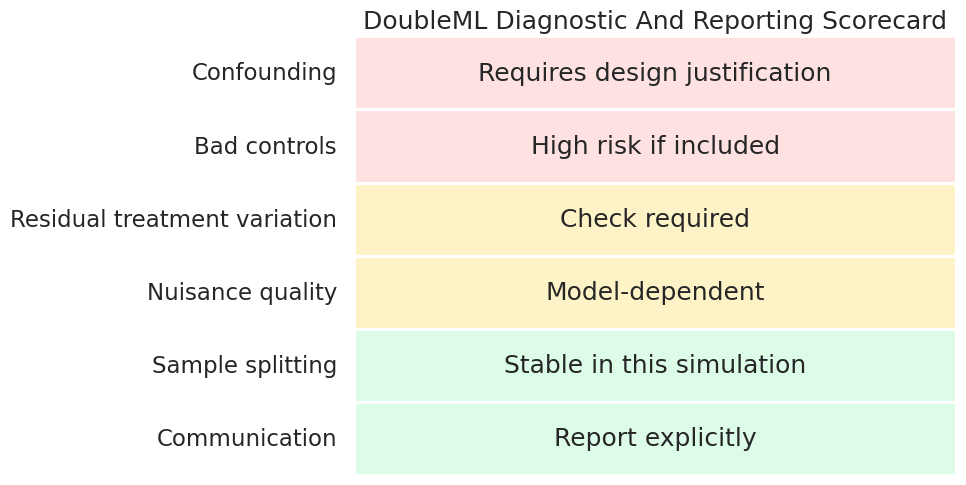

In [17]:
status_order = {
    "Stable in this simulation": 1,
    "Report explicitly": 1,
    "Check required": 2,
    "Model-dependent": 2,
    "Requires design justification": 3,
    "High risk if included": 3,
}
scorecard_plot = scorecard.assign(risk_level=scorecard["status"].map(status_order))

fig, ax = plt.subplots(figsize=(10, 5.2))
heatmap_data = scorecard_plot.set_index("risk_area")[["risk_level"]]
sns.heatmap(
    heatmap_data,
    annot=scorecard_plot.set_index("risk_area")[["status"]],
    fmt="",
    cmap=sns.color_palette(["#dcfce7", "#fef3c7", "#fee2e2"], as_cmap=True),
    cbar=False,
    linewidths=1,
    linecolor="#ffffff",
    xticklabels=False,
    ax=ax,
)
ax.set_title("DoubleML Diagnostic And Reporting Scorecard")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", bottom=False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_diagnostic_scorecard.png", dpi=160, bbox_inches="tight")
plt.show()

The heatmap keeps the report honest: some items can be checked numerically, while others remain design assumptions. The red cells are not failures by themselves; they are places where a serious report needs careful language.

## Reporting Template

This cell writes a reusable Markdown report template. It is deliberately structured around the things that usually go missing: target estimand, feature timing, learner settings, split design, diagnostics, sensitivity checks, and limitations.

In [18]:
report_template = f"""# DoubleML Diagnostics And Reporting Template

## 1. Causal Question
State the treatment, outcome, population, and target estimand. For PLR, write whether the target is a constant marginal effect like $\theta_0$.

## 2. Identification Assumptions
Describe the adjustment set, timing of all controls, unconfoundedness assumptions, overlap or residual treatment variation, and any reasons these assumptions may fail.

## 3. Data And Feature Timing
List every feature group and classify it as pre-treatment, treatment, mediator, outcome, post-treatment, or future information. Exclude post-treatment controls from the main design.

## 4. DoubleML Specification
Report the DoubleML class, score, learners for each nuisance function, fold count, repeated-split count, random seeds, and whether sample splitting was supplied externally.

## 5. Main Estimate
Report estimate, standard error, confidence interval, and sample size. Explain the units of treatment and outcome.

## 6. Diagnostics
Include nuisance RMSE, residualized-treatment variation, score denominator, sample-split stability, and any learner-comparison results.

## 7. Robustness And Sensitivity
Discuss omitted-confounder risk, alternative adjustment sets, weak-overlap checks, and whether the estimate changes under defensible specifications.

## 8. Limitations
State what the analysis cannot prove. DoubleML does not repair missing confounders, bad controls, interference, measurement error, or target mismatch.

## 9. Artifact Paths From This Notebook
- Pitfall map: {TABLE_DIR / f'{NOTEBOOK_PREFIX}_pitfall_map.csv'}
- Control-set scenarios: {TABLE_DIR / f'{NOTEBOOK_PREFIX}_control_set_scenarios.csv'}
- Residual treatment variation: {TABLE_DIR / f'{NOTEBOOK_PREFIX}_residual_treatment_variation.csv'}
- Nuisance learner comparison: {TABLE_DIR / f'{NOTEBOOK_PREFIX}_nuisance_learner_comparison.csv'}
- Sample-split summary: {TABLE_DIR / f'{NOTEBOOK_PREFIX}_sample_split_summary.csv'}
- Diagnostic scorecard: {TABLE_DIR / f'{NOTEBOOK_PREFIX}_diagnostic_scorecard.csv'}
"""

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_diagnostics_reporting_template.md"
report_path.write_text(report_template)
print(f"Wrote report template to: {report_path}")

Wrote report template to: /home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs/reports/17_diagnostics_reporting_template.md


The template is meant to be copied forward into real analyses. It also makes the tutorial concrete: every major claim made by the notebook has a corresponding artifact path.

## Artifact Manifest

The final table lists the datasets, tables, figures, and report generated by this notebook. This is useful when reviewing the tutorial later or when turning it into a portfolio-style writeup.

In [19]:
artifact_manifest = pd.DataFrame(
    [
        {"artifact": "Confounding pitfall dataset", "path": str(DATASET_DIR / f"{NOTEBOOK_PREFIX}_confounding_pitfall_data.csv")},
        {"artifact": "Nonlinear nuisance dataset", "path": str(DATASET_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_nuisance_data.csv")},
        {"artifact": "Pitfall map", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pitfall_map.csv")},
        {"artifact": "Control-set scenarios", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_control_set_scenarios.csv")},
        {"artifact": "Control-set diagnostics", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_control_set_diagnostics.csv")},
        {"artifact": "Residual treatment variation", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_residual_treatment_variation.csv")},
        {"artifact": "Nuisance learner comparison", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_nuisance_learner_comparison.csv")},
        {"artifact": "Sample-split repetitions", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_split_repetitions.csv")},
        {"artifact": "Diagnostic scorecard", "path": str(TABLE_DIR / f"{NOTEBOOK_PREFIX}_diagnostic_scorecard.csv")},
        {"artifact": "Control-set DAG", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_control_set_pitfall_dag.png")},
        {"artifact": "Control-set estimate plot", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_control_set_estimates.png")},
        {"artifact": "Residualized treatment plot", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_residualized_treatment_distributions.png")},
        {"artifact": "Nuisance learner plot", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nuisance_learner_diagnostics.png")},
        {"artifact": "Sample-split plot", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_split_stability.png")},
        {"artifact": "Scorecard plot", "path": str(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_diagnostic_scorecard.png")},
        {"artifact": "Reporting template", "path": str(REPORT_DIR / f"{NOTEBOOK_PREFIX}_diagnostics_reporting_template.md")},
    ]
)

save_table(artifact_manifest, f"{NOTEBOOK_PREFIX}_artifact_manifest.csv")
display(artifact_manifest)

,artifact,path
0,Confounding pitfall dataset,/home/apex/Documents/ranking_sys/notebooks/tut...
1,Nonlinear nuisance dataset,/home/apex/Documents/ranking_sys/notebooks/tut...
2,Pitfall map,/home/apex/Documents/ranking_sys/notebooks/tut...
3,Control-set scenarios,/home/apex/Documents/ranking_sys/notebooks/tut...
4,Control-set diagnostics,/home/apex/Documents/ranking_sys/notebooks/tut...
5,Residual treatment variation,/home/apex/Documents/ranking_sys/notebooks/tut...
6,Nuisance learner comparison,/home/apex/Documents/ranking_sys/notebooks/tut...
7,Sample-split repetitions,/home/apex/Documents/ranking_sys/notebooks/tut...
8,Diagnostic scorecard,/home/apex/Documents/ranking_sys/notebooks/tut...
9,Control-set DAG,/home/apex/Documents/ranking_sys/notebooks/tut...


The manifest closes the loop between notebook analysis and reviewable outputs. A strong causal notebook should leave behind more than printed estimates; it should leave behind enough structure for another person to audit the design.

## What Comes Next

The next tutorial is the end-to-end DoubleML case study. That notebook should combine the lessons from this series: clear causal question, correct data backend, suitable estimator class, deliberate learners, cross-fitting diagnostics, uncertainty, sensitivity, pitfalls, and a concise final report.

The main lesson from this notebook is simple: DoubleML is not magic. It is a disciplined way to estimate orthogonal scores after you have done the causal design work. The best analysts do not just produce an estimate; they show why that estimate deserves attention and where it could still fail.